# Projekat: Klasifikacija pecuraka (Edible vs Poisinous)
**Tema**: Nadgledano ucenje - Klasifikacija

**Dataset**: [Mushroom Classification (Kaggle - Biology)](https://www.kaggle.com/datasets/uciml/mushroom-classification)

## Definicija problema i ucitavanje podataka
### Cilj: Na osnovu fizickih karakteristika pecurke predvideti da li je otrovna ili jestiva.

### Ucitavanje biblioteka i skupa podataka.


In [364]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import shap
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV
from lime.lime_tabular import LimeTabularExplainer
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

In [365]:
df = pd.read_csv('data/mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Opis atributa 

- <b>class</b>: Klasa (Cilj): edible=e (jestiva), poisonous=p (otrovna)

- <b>cap-shape</b>: Oblik sesira: bell=b (zvonast), conical=c (kupast), convex=x (ispupcen), flat=f (ravan), knobbed=k (kvrgav/izbocen), sunken=s (udubljen)

- <b>cap-surface</b>: Povrsina sesira: fibrous=f (vlaknasta), grooves=g (zljebovita), scaly=y (ljuspasta), smooth=s (glatka)

- <b>cap-color</b>: Boja sesira: brown=n (braon), buff=b (bez/zutosmedja), cinnamon=c (cimet), gray=g (siva), green=r (zelena), pink=p (roze), purple=u (ljubicasta), red=e (crvena), white=w (bela), yellow=y (zuta)

- <b>bruises</b>: Uboji (modrice/ostecenja): bruises=t (ima), no=f (nema)

- <b>odor</b>: Miris: almond=a (badem), anise=l (anis), creosote=c (kreozot/dim), fishy=y (riba), foul=f (uzasan/trulez), musty=m (budjav), none=n (bez mirisa), pungent=p (ostar/ljut), spicy=s (zacinski)

- <b>gill-attachment</b>: Prianjanje listica (za drsku): attached=a (pripojeni), descending=d (silazni), free=f (slobodni), notched=n (nazubljeni)

- <b>gill-spacing</b>: Razmak listica: close=c (blizu), crowded=w (zbijeni), distant=d (razmaknuti)

- <b>gill-size</b>: Velicina listica: broad=b (siroki), narrow=n (uski)

- <b>gill-color</b>: Boja listica: black=k (crna), brown=n (braon), buff=b (bez), chocolate=h (cokoladna), gray=g (siva), green=r (zelena), orange=o (narandzasta), pink=p (roze), purple=u (ljubicasta), red=e (crvena), white=w (bela), yellow=y (zuta)

- <b>stalk-shape</b>: Oblik drske: enlarging=e (prosiruje se), tapering=t (suzava se)

- <b>stalk-root</b>: Koren drske: bulbous=b (lukovicast), club=c (batinast), cup=u (casast), equal=e (jednak), rhizomorphs=z (rizomorfi/koncici), rooted=r (ukorenjen), missing=? (nepoznato/nedostaje)

- <b>stalk-surface-above-ring</b>: Povrsina drske iznad prstena: fibrous=f (vlaknasta), scaly=y (ljuspasta), silky=k (svilenkasta), smooth=s (glatka)

- <b>stalk-surface-below-ring</b>: Povrsina drske ispod prstena: fibrous=f (vlaknasta), scaly=y (ljuspasta), silky=k (svilenkasta), smooth=s (glatka)

- <b>stalk-color-above-ring</b>: Boja drske iznad prstena: brown=n (braon), buff=b (bez), cinnamon=c (cimet), gray=g (siva), orange=o (narandzasta), pink=p (roze), red=e (crvena), white=w (bela), yellow=y (zuta)

- <b>stalk-color-below-ring</b>: Boja drske ispod prstena: (iste boje kao iznad)

- <b>veil-type</b>: Tip vela: partial=p (delimican), universal=u (univerzalan)

- <b>veil-color</b>: Boja vela: brown=n (braon), orange=o (narandzasta), white=w (bela), yellow=y (zuta)

- <b>ring-number</b>: Broj prstenova: none=n (nema), one=o (jedan), two=t (dva)

- <b>ring-type</b>: Tip prstena: cobwebby=c (paucinast), evanescent=e (nestalan/prolazan), flaring=f (siri se/levkast), large=l (veliki), none=n (nema), pendant=p (viseci), sheathing=s (obavijen), zone=z (zona)

- <b>spore-print-color</b>: Boja spora (otisak): black=k (crna), brown=n (braon), buff=b (bez), chocolate=h (cokoladna), green=r (zelena), orange=o (narandzasta), purple=u (ljubicasta), white=w (bela), yellow=y (zuta)

- <b>population</b>: Populacija (kako rastu): abundant=a (izobilna), clustered=c (grupisana/klasteri), numerous=n (brojna), scattered=s (rastrkana), several=v (nekoliko), solitary=y (usamljena)

- <b>habitat</b>: Staniste: grasses=g (trava), leaves=l (lisce), meadows=m (livade), paths=p (staze), urban=u (urbano), waste=w (otpad), woods=d (suma)

## Deskriptivna analiza i priprema podataka

### Tipovi podataka

In [366]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [367]:
df.shape

(8124, 23)

### Provera nedostatka i duplikata

In [368]:
null_counts = df.isnull().sum()
total_null = null_counts.sum()
print(f"Broj nedostajucih vrednosti u celom datasetu: {total_null}")

dupes = df.duplicated().sum()
print(f"Pronadjeno {dupes} duplikata")

Broj nedostajucih vrednosti u celom datasetu: 0
Pronadjeno 0 duplikata


### Detaljan prikaz atributa u odnosu na klasu (da li je jestiva ili ne)

#### Balans klasa

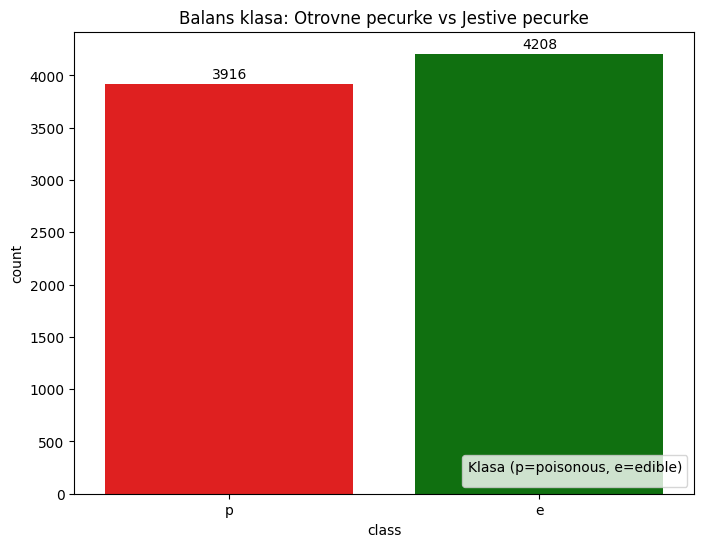

In [369]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    x='class', 
    data=df, 
    hue='class',
    legend=False,
    palette=['red', 'green'] 
)

plt.title('Balans klasa: Otrovne pecurke vs Jestive pecurke')
plt.legend(title='Klasa (p=poisonous, e=edible)', loc='lower right')

for container in ax.containers:
    ax.bar_label(container, padding=2)

plt.show()


#### Distribucija razlicitih cap atributa

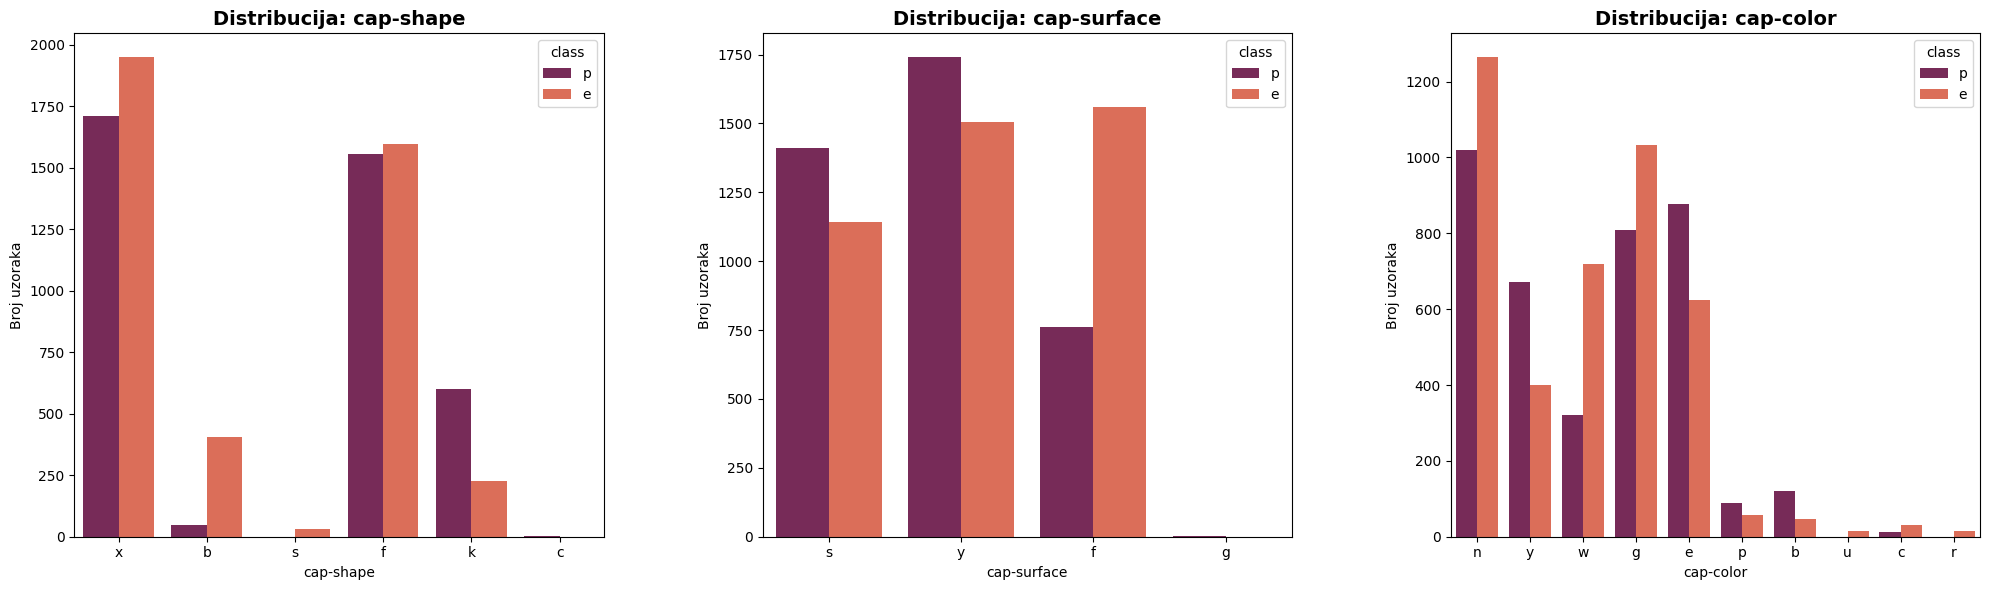

In [370]:
features = ['cap-shape', 'cap-surface', 'cap-color']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

for i, col in enumerate(features):
    sns.countplot(x=col, hue='class', data=df, palette="rocket", ax=axes[i])
    axes[i].set_title(f'Distribucija: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()

#### Distribucija bruises

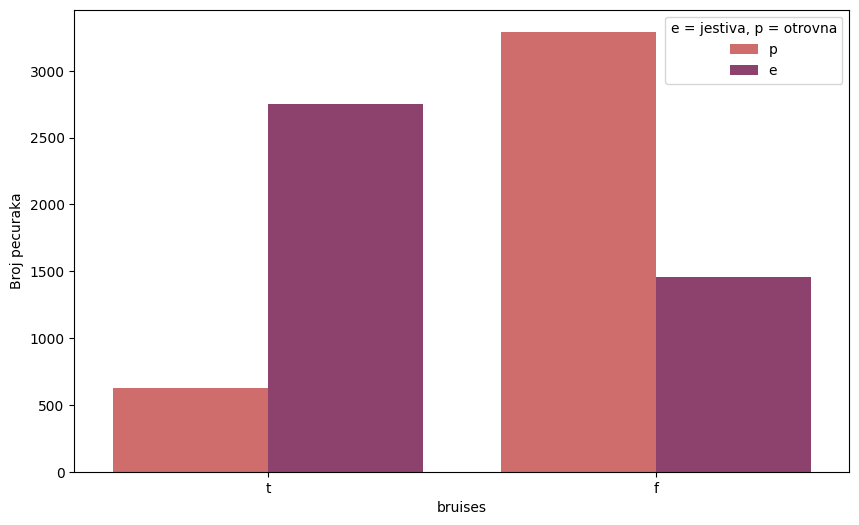

In [371]:
plt.figure(figsize=(10, 6))

sns.countplot(x='bruises', hue='class', data=df, palette='flare')

plt.ylabel('Broj pecuraka')
plt.legend(title='e = jestiva, p = otrovna', loc='upper right')

plt.show()

#### Distribucija odora

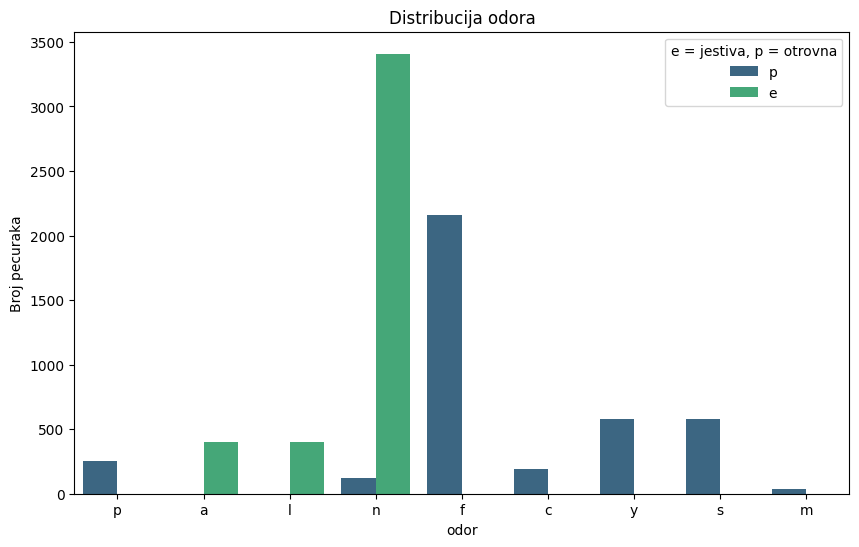

In [372]:
plt.figure(figsize=(10, 6))

sns.countplot(x='odor', hue='class', data=df, palette='viridis')

plt.title('Distribucija odora')
plt.ylabel('Broj pecuraka')
plt.legend(title='e = jestiva, p = otrovna', loc='upper right')


plt.show()

#### Distribucija gill atributa

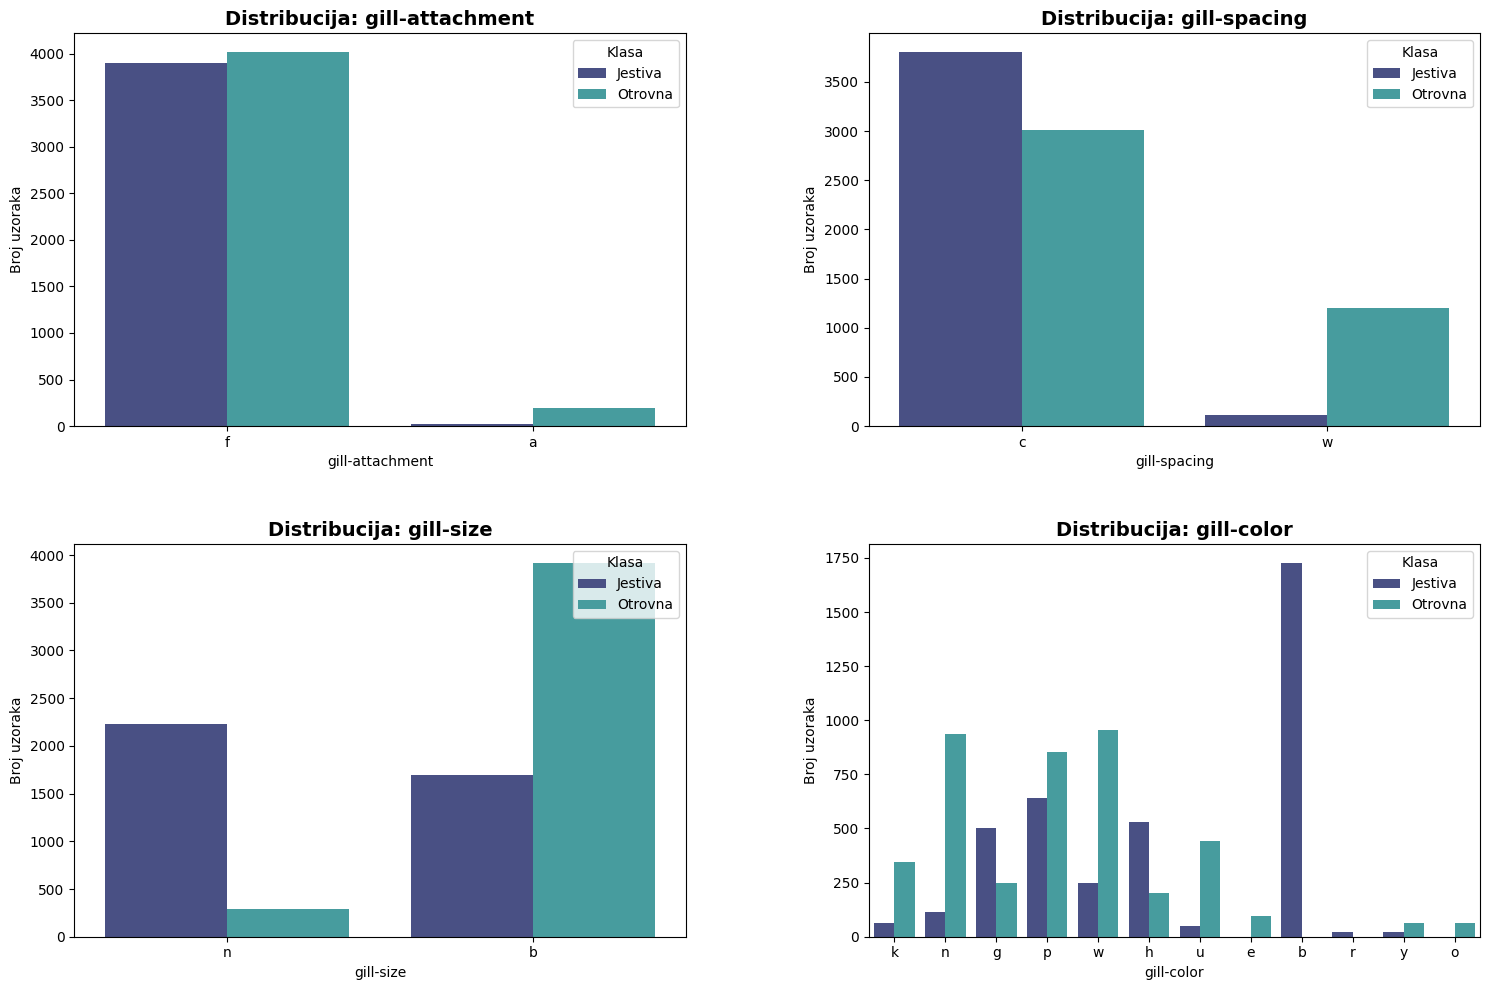

In [373]:
features = ['gill-attachment', 'gill-spacing', 'gill-size', 'gill-color']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

axes = axes.flatten() 

for i, col in enumerate(features):
    sns.countplot(x=col, hue='class', data=df, palette='mako', ax=axes[i])
    
    axes[i].set_title(f'Distribucija: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].legend(title='Klasa', labels=['Jestiva', 'Otrovna'], loc='upper right')


plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

#### Distribucija korena (stalk)

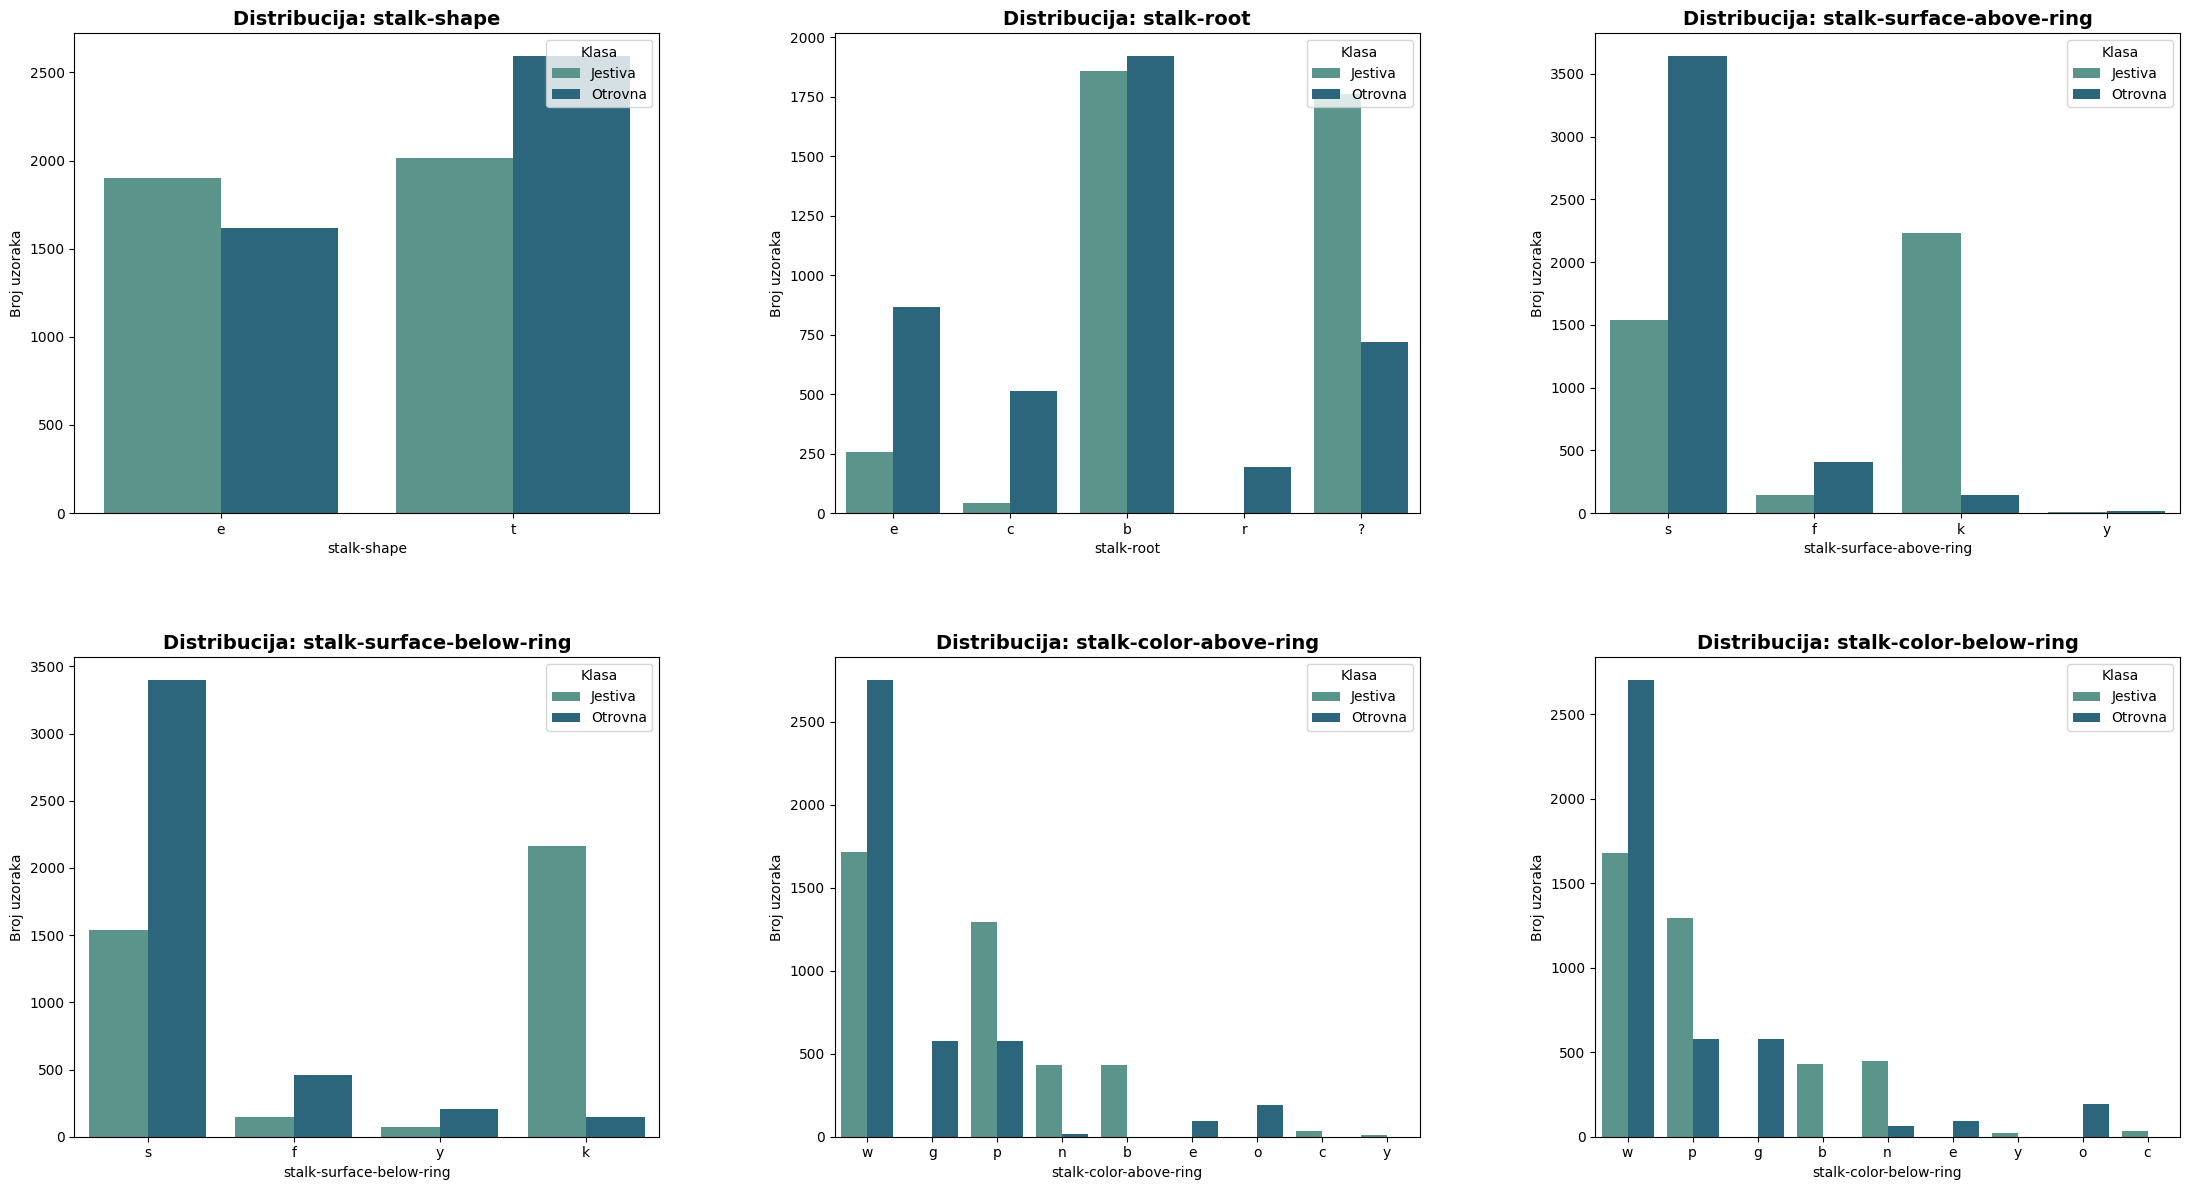

In [374]:
stalk_features = ['stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(22, 12))

axes = axes.flatten() 

for i, col in enumerate(stalk_features):
    sns.countplot(x=col, hue='class', data=df, palette='crest', ax=axes[i])
    
    axes[i].set_title(f'Distribucija: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].legend(title='Klasa', labels=['Jestiva', 'Otrovna'], loc='upper right')

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

#### Detaljan prikaz samo distribucije vrste korena

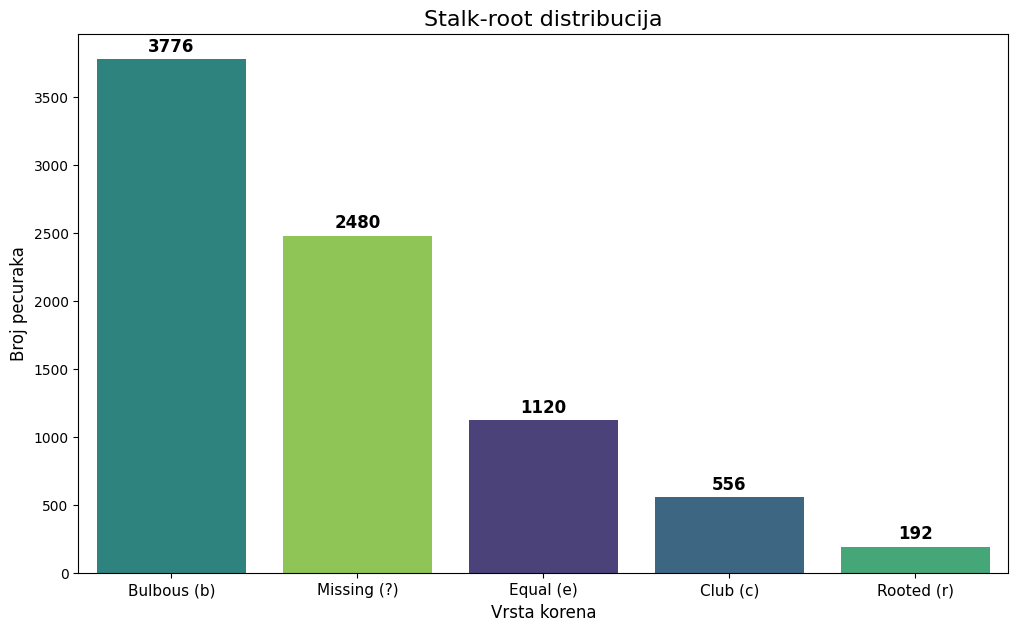

In [375]:
plt.figure(figsize=(12, 7))

df_viz = df.copy()

mapping = {
    'b': 'Bulbous (b)',
    '?': 'Missing (?)',
    'e': 'Equal (e)',
    'c': 'Club (c)',
    'r': 'Rooted (r)'
}

df_viz['stalk-root'] = df_viz['stalk-root'].map(mapping)

ax = sns.countplot(
    x='stalk-root', 
    data=df_viz, 
    hue='stalk-root',
    legend=False,
    palette='viridis',
    order=df_viz['stalk-root'].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container, fontsize=12, padding=3, fontweight='bold')

plt.title('Stalk-root distribucija', fontsize=16)
plt.xlabel('Vrsta korena', fontsize=12)
plt.ylabel('Broj pecuraka', fontsize=12)
plt.xticks(fontsize=11)

plt.show()

### Zamena ? u "Unknown" radi tehnicke ispravnosti (One-Hot Encoding) i bolje interpretacije modela

In [376]:
df['stalk-root'] = df['stalk-root'].replace('?', 'Unknown')

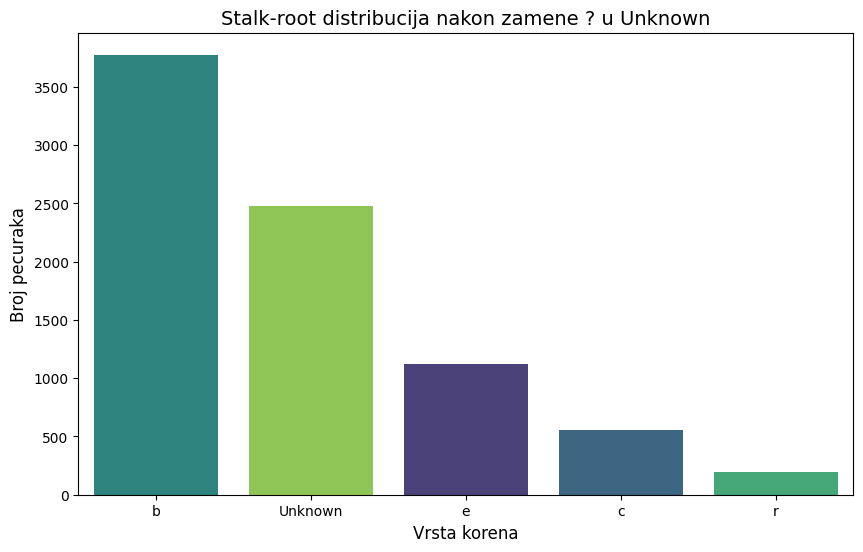

In [377]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    x='stalk-root',
    data=df,
    hue='stalk-root',
    legend=False,
    palette='viridis',
    order=df['stalk-root'].value_counts().index
)

plt.title('Stalk-root distribucija nakon zamene ? u Unknown', fontsize=14)
plt.xlabel('Vrsta korena', fontsize=12)
plt.ylabel('Broj pecuraka', fontsize=12)

plt.show()

#### Distribucija vela

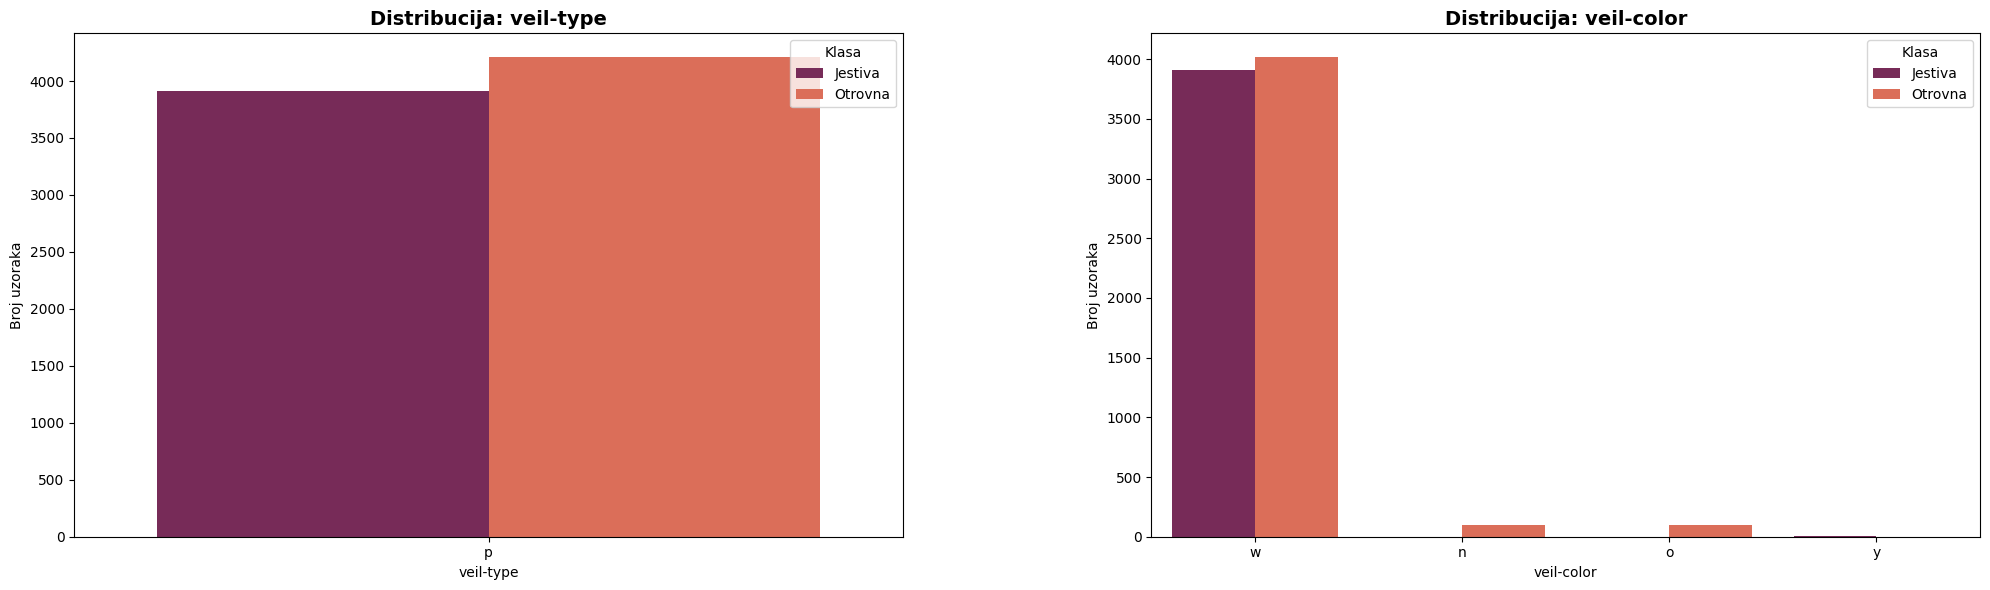

In [378]:
veil_features = ['veil-type', 'veil-color']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

axes = axes.flatten() 

for i, col in enumerate(veil_features):
    sns.countplot(x=col, hue='class', data=df, palette='rocket', ax=axes[i])
    
    axes[i].set_title(f'Distribucija: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].legend(title='Klasa', labels=['Jestiva', 'Otrovna'], loc='upper right')

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

#### Distribucija prstenova

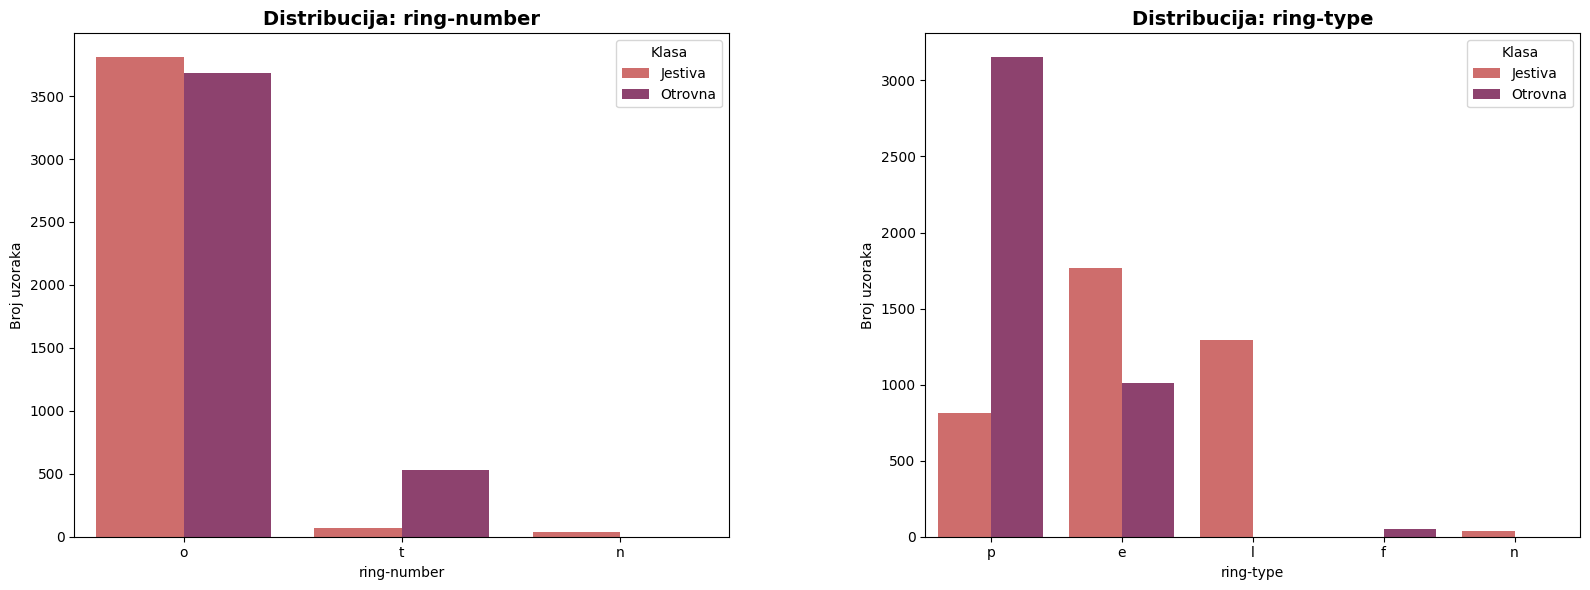

In [379]:
ring_features = ['ring-number', 'ring-type']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(ring_features):
    sns.countplot(x=col, hue='class', data=df, palette='flare', ax=axes[i])
    
    axes[i].set_title(f'Distribucija: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].legend(title='Klasa', labels=['Jestiva', 'Otrovna'], loc='upper right')

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()

#### Distribucija ostalih atributa

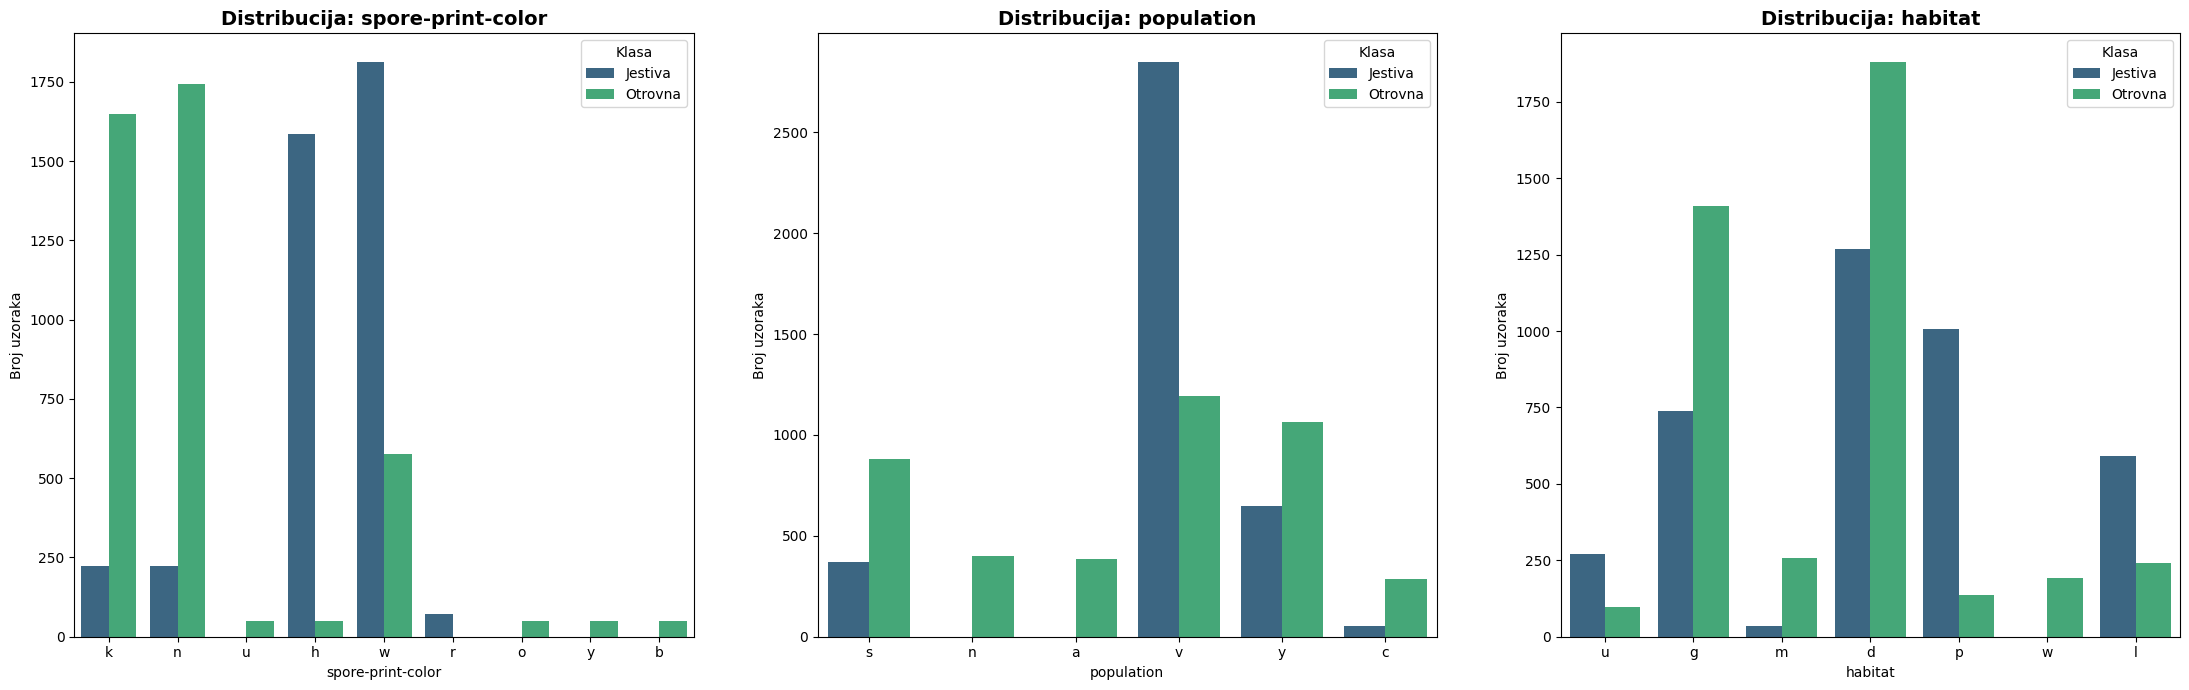

In [380]:
misc_features = ['spore-print-color', 'population', 'habitat']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 7))
axes = axes.flatten()

for i, col in enumerate(misc_features):
    sns.countplot(x=col, hue='class', data=df, palette='viridis', ax=axes[i])
    
    axes[i].set_title(f'Distribucija: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].legend(title='Klasa', labels=['Jestiva', 'Otrovna'], loc='upper right')

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
plt.show()

### Promene tipova podataka u integer radi prikaza heatmape

In [381]:
df_copy = df.copy()
encoding = LabelEncoder

le = LabelEncoder()

for col in df_copy.columns:
    df_copy[col] = le.fit_transform(df_copy[col])

df_copy.info()
df_copy.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   int64
 1   cap-shape                 8124 non-null   int64
 2   cap-surface               8124 non-null   int64
 3   cap-color                 8124 non-null   int64
 4   bruises                   8124 non-null   int64
 5   odor                      8124 non-null   int64
 6   gill-attachment           8124 non-null   int64
 7   gill-spacing              8124 non-null   int64
 8   gill-size                 8124 non-null   int64
 9   gill-color                8124 non-null   int64
 10  stalk-shape               8124 non-null   int64
 11  stalk-root                8124 non-null   int64
 12  stalk-surface-above-ring  8124 non-null   int64
 13  stalk-surface-below-ring  8124 non-null   int64
 14  stalk-color-above-ring    8124 non-null 

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


### Prikaz toplotne mape

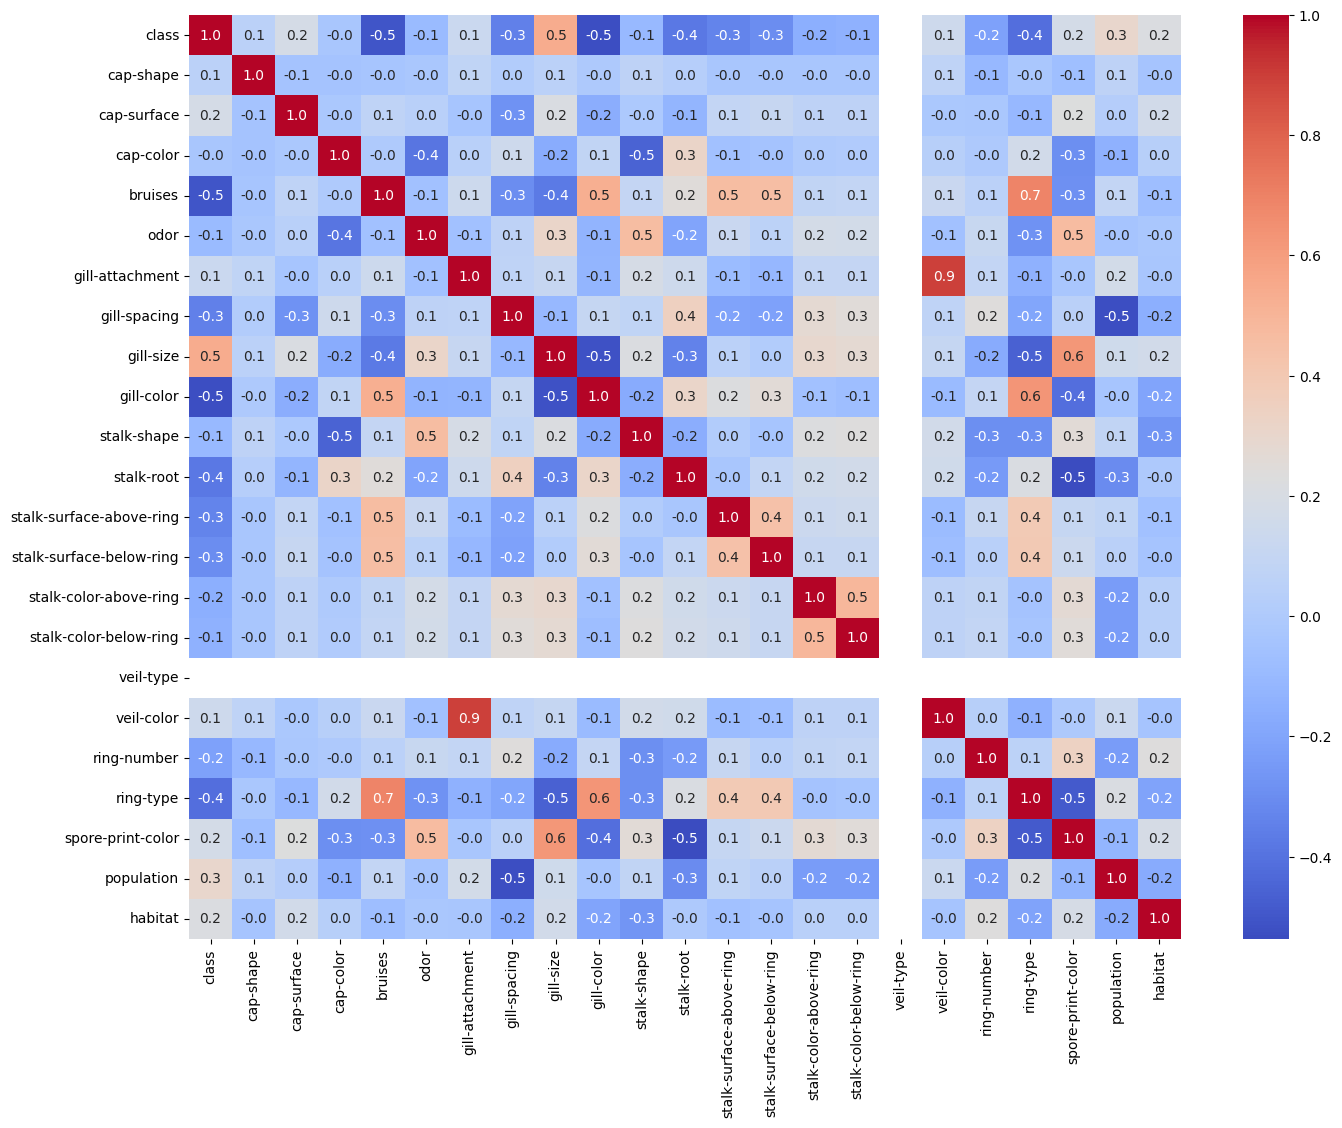

In [382]:
plt.figure(figsize=(16, 12))

sns.heatmap(df_copy.corr(), annot=True, fmt='.1f', cmap='coolwarm')

plt.show()

Graficki prikaz jasno pokazuje da atribut veil-type (tip vela) poseduje nultu varijansu. Svih 8124 uzoraka u skupu podataka imaju identicnu vrednost ('p' - partial). Ovo nece uticati na krajnji cilj modela, zato mozemo da ga uklonimo

### Prikaz topoltne mape bez veil-type atributa

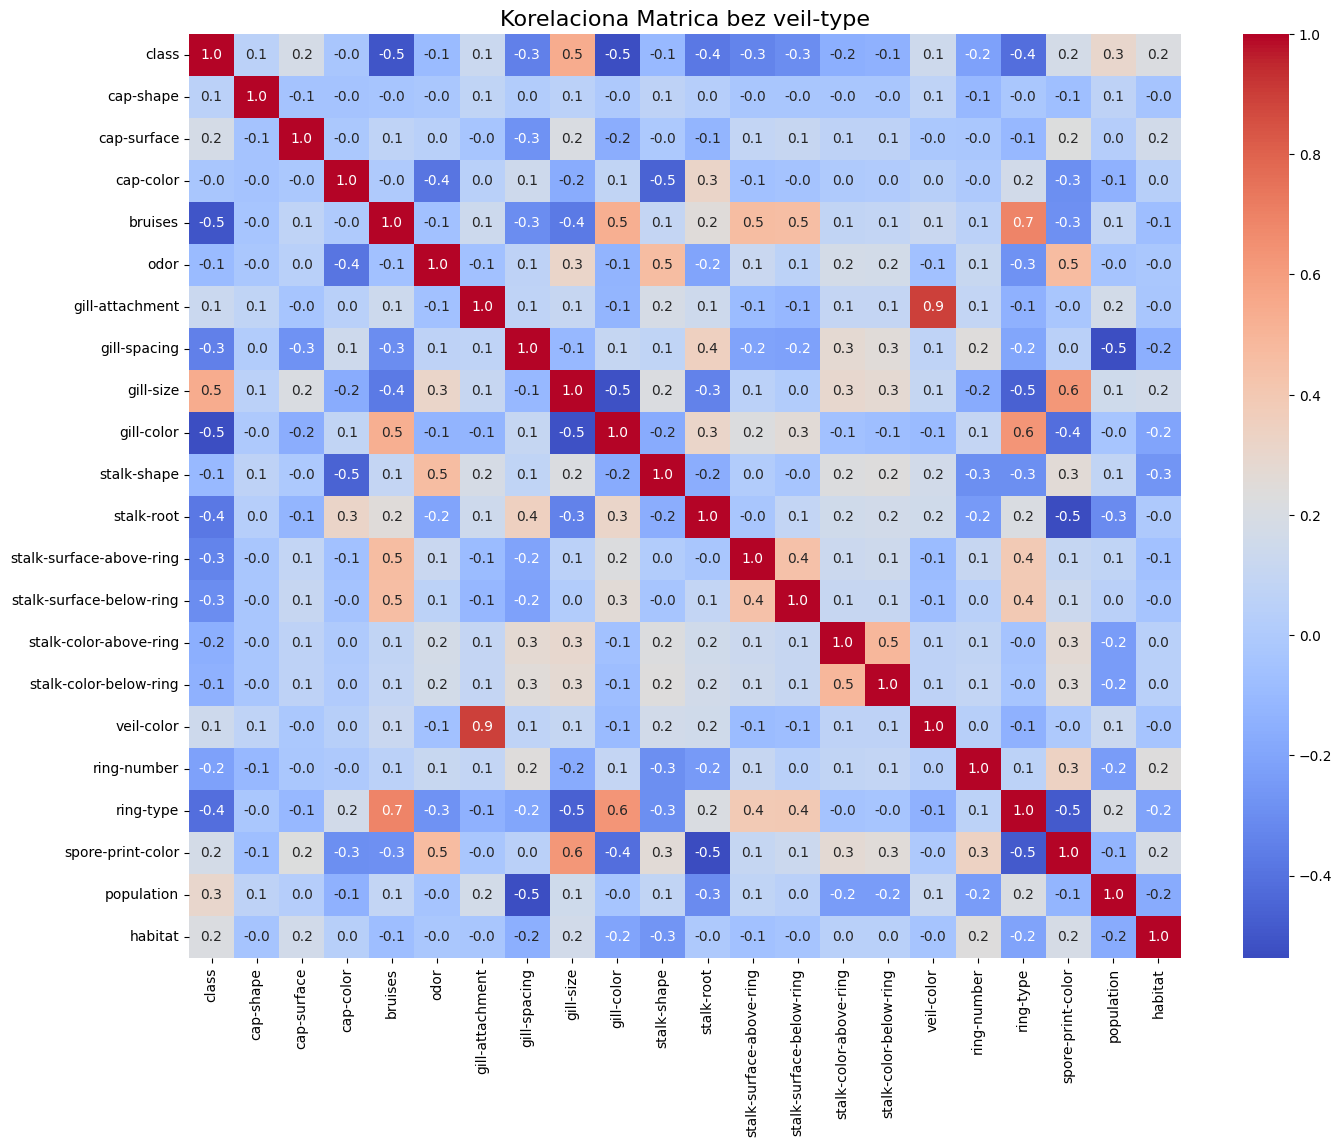

In [383]:
df_copy = df_copy.drop('veil-type', axis=1)

plt.figure(figsize=(16, 12))
sns.heatmap(df_copy.corr(), annot=True, fmt='.1f', cmap='coolwarm')
plt.title('Korelaciona Matrica bez veil-type', fontsize=16)

plt.show()

### Prikaz atributa koji najvise odaju otrovnu pecurku

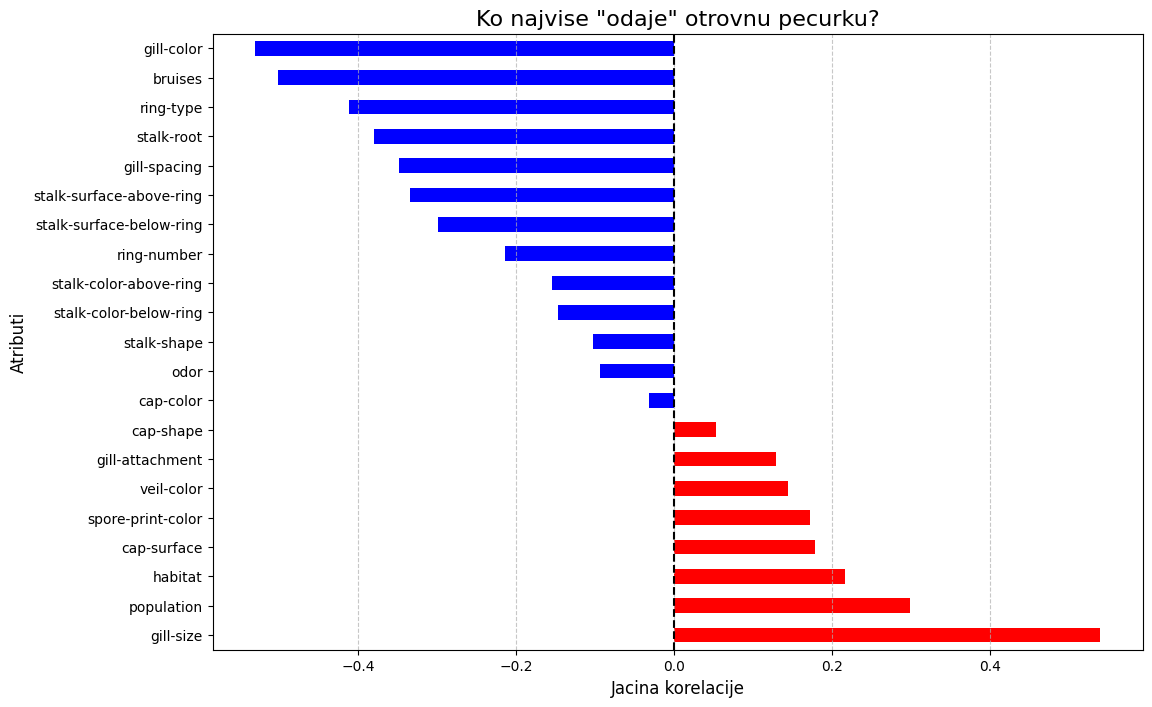

In [384]:
target_corr = df_copy.corr()['class'].sort_values(ascending=False)

target_corr = target_corr.drop('class')

plt.figure(figsize=(12, 8))
target_corr.plot(kind='barh', color=target_corr.apply(lambda x: 'red' if x > 0 else 'blue'))

plt.title('Ko najvise "odaje" otrovnu pecurku?', fontsize=16)
plt.xlabel('Jacina korelacije', fontsize=12)
plt.ylabel('Atributi', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)

### Modifikacija originalnog skupa podataka

In [385]:
if 'veil-type' in df.columns:
    df.drop('veil-type', axis=1, inplace=True) 
    print("Obrisan 'veil-type' iz originala.")

print(f"\nTrenutne dimenzije df-a: {df.shape}")


Obrisan 'veil-type' iz originala.

Trenutne dimenzije df-a: (8124, 22)


### Sistemski pregled

In [386]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,4,9,9,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,s,w,w,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,5176,4936,4464,4384,7924,7488,3968,2388,4040,3148


## Modelovanje Algoritama

### Spremanje podataka za treniranje

In [387]:
print("="*60)
print("Konvertujemo podatke tako da model moze da razume")
print("="*60)

# One-hot Encoding
X = pd.get_dummies(df.drop('class', axis=1), drop_first=True)
y = df['class']

y = y.map({'e': 0, 'p': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nPodaci za treniranje: {len(X_train):,} (80%)")
print(f"Podaci za testiranje:  {len(X_test):,} (20%)")
print(f"\nBroj kolona: {X.shape[1]}")

print(f"\nRaspodela ciljne promenljive u skupu za treniranje:")
print(f"  Jestive:    {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Otrovne: {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")

print(f"\nRaspodela ciljne promenljive u skupu za testiranje::")
print(f"  Jestive:    {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  Otrovne: {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")


Konvertujemo podatke tako da model moze da razume

Podaci za treniranje: 6,499 (80%)
Podaci za testiranje:  1,625 (20%)

Broj kolona: 95

Raspodela ciljne promenljive u skupu za treniranje:
  Jestive:    3366 (51.8%)
  Otrovne: 3133 (48.2%)

Raspodela ciljne promenljive u skupu za testiranje::
  Jestive:    842 (51.8%)
  Otrovne: 783 (48.2%)


### Algoritmi za treniranje

In [388]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}


print("Algoritmi:")


for i, name in enumerate(models.keys(), 1):
    print(f" {i}.{name}")


Algoritmi:
 1.Logistic Regression
 2.Random Forest
 3.Support Vector Machine
 4.K-Nearest Neighbors


MODEL                     | ACCURACY   | RECALL          | PRECISION  | F1 SCORE   | CV MEAN   
----------------------------------------------------------------------------------------------------
Logistic Regression       | 99.88%    |    99.74%   |   100.00%   |   99.87%   | 99.92%
Random Forest             | 100.00%    |    100.00%   |   100.00%   |   100.00%   | 99.97%
Support Vector Machine    | 100.00%    |    100.00%   |   100.00%   |   100.00%   | 99.94%
K-Nearest Neighbors       | 100.00%    |    100.00%   |   100.00%   |   100.00%   | 99.94%
----------------------------------------------------------------------------------------------------


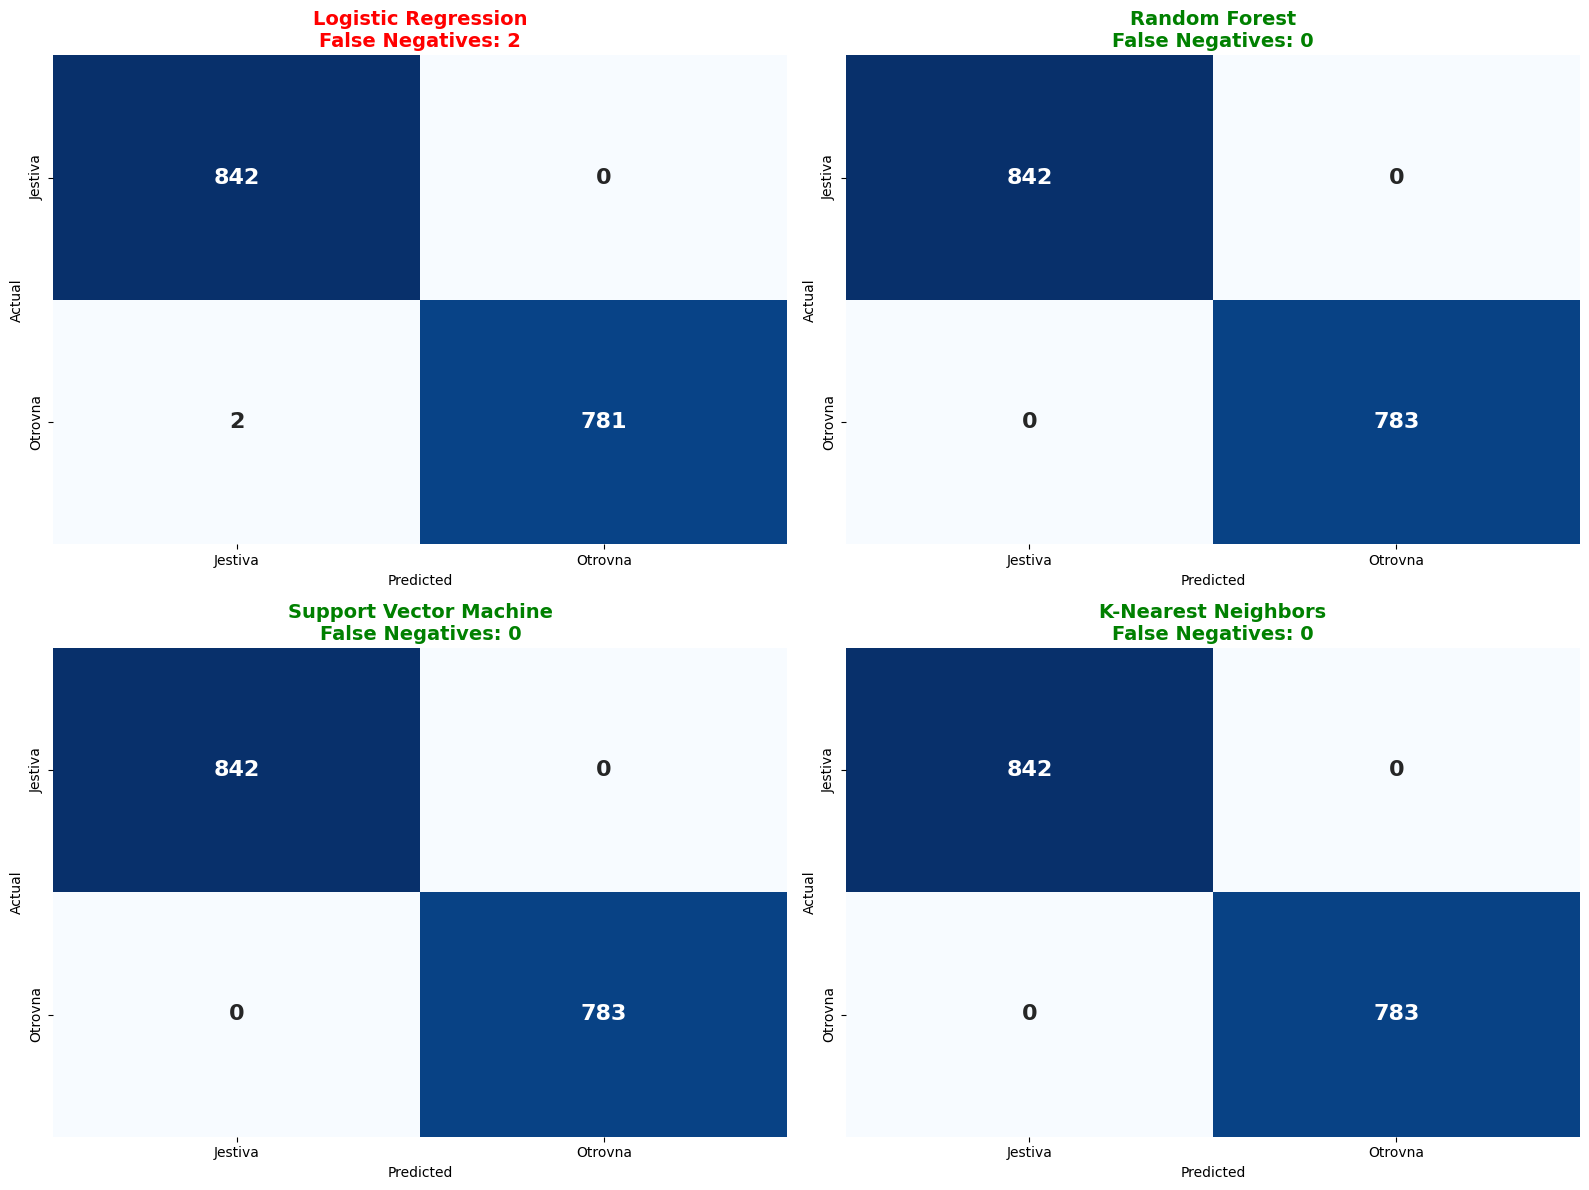

In [389]:
results = []

ig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

print(f"{'MODEL':<25} | {'ACCURACY':<10} | {'RECALL':<15} | {'PRECISION':<10} | {'F1 SCORE':<10} | {'CV MEAN':<10}")
print("-"*100)

for i, (name, model) in enumerate(models.items()):
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)


    # Izrucavanje metrika
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Cross-Validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Cross-Val': cv_scores.mean()
    })

    print(f"{name:<25} | {acc:.2%}    |    {rec:.2%}   |   {prec:.2%}   |   {f1:.2%}   | {cv_scores.mean():.2%}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Jestiva', 'Otrovna'],
                yticklabels=['Jestiva', 'Otrovna'],
                annot_kws={'size': 16, 'weight': 'bold'}, cbar=False)

    fn_count = cm[1, 0]
    title_color = 'red' if fn_count > 0 else 'green'
    axes[i].set_title(f"{name}\nFalse Negatives: {fn_count}", fontsize=14, fontweight='bold', color=title_color)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

print("-"*100)

plt.tight_layout()
plt.show()

### Uporedjivanje i pregled dobijenih rezultata

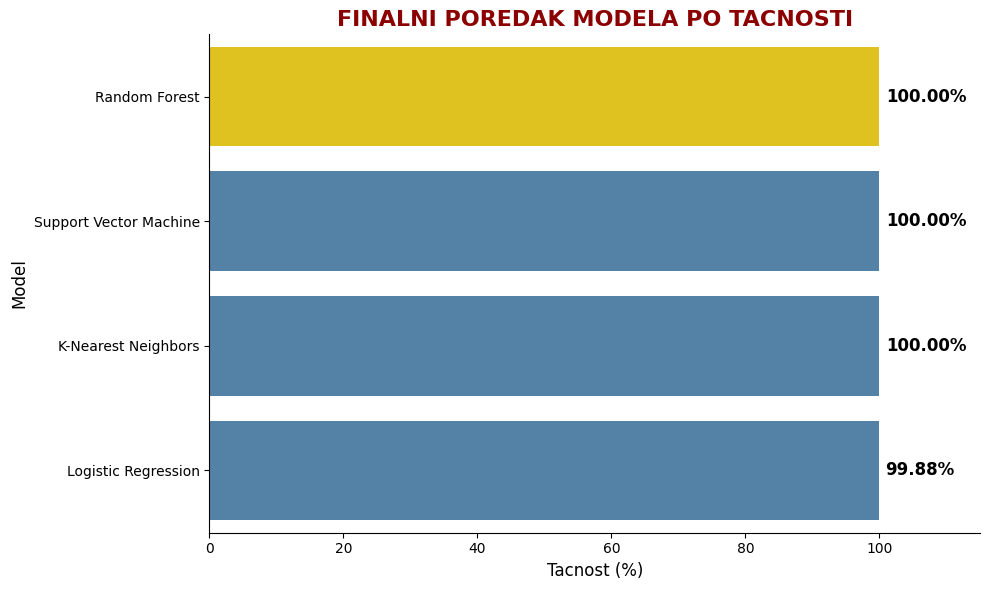

In [390]:
leaderboard_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)

leaderboard_df['Accuracy %'] = leaderboard_df['Accuracy'] * 100

colors = ['gold' if i == 0 else 'steelblue' for i in range(len(leaderboard_df))]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='Accuracy %', 
    y='Model', 
    data=leaderboard_df, 
    palette=colors
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=5, fontsize=12, fontweight='bold')

plt.title('FINALNI POREDAK MODELA PO TACNOSTI', fontsize=16, fontweight='bold', color='darkred')
plt.xlabel('Tacnost (%)', fontsize=12)
plt.ylabel('Model', fontsize=12)

plt.xlim(0, 115) 

sns.despine()

plt.tight_layout()
plt.show()

In [391]:
display(leaderboard_df)

,Model,Accuracy,Precision,Recall,F1-Score,Cross-Val,Accuracy %
1,Random Forest,1.000000,1.0,1.000000,1.000000,0.999692,100.000000
2,Support Vector Machine,1.000000,1.0,1.000000,1.000000,0.999385,100.000000
3,K-Nearest Neighbors,1.000000,1.0,1.000000,1.000000,0.999385,100.000000
0,Logistic Regression,0.998769,1.0,0.997446,0.998721,0.999231,99.876923


### Optimizacija hiperparametara Random Forest algoritma

In [392]:
rf = models['Random Forest']

parameters = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'criterion': ['gini', 'entropy']
}

grid_rf = GridSearchCV(
    estimator=rf, 
    param_grid=parameters, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("\nREZULTATI:")
print(f"Najbolja tacnost na treningu: {grid_rf.best_score_:.2%}")
print("Najbolji parametri:")
print(grid_rf.best_params_)

random_forest_best = grid_rf.best_estimator_


REZULTATI:
Najbolja tacnost na treningu: 99.98%
Najbolji parametri:
{'criterion': 'gini', 'max_depth': 20, 'n_estimators': 200}


### Optimizacija parametara za Support Vector Machine

In [393]:
svm = models["Support Vector Machine"]

parameters_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.1, 1]
}

grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=parameters_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("\nREZULTATI SVM:")
print(f"Najbolja tacnost na treningu: {grid_svm.best_score_:.2%}")
print("Najbolji parametri:")
print(grid_svm.best_params_)

svm_best = grid_svm.best_estimator_


REZULTATI SVM:
Najbolja tacnost na treningu: 100.00%
Najbolji parametri:
{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


In [394]:
y_pred_champion = random_forest_best.predict(X_test)
y_pred_champion_svm = svm_best.predict(X_test)

print("="*60)
print(f"KONACNI IZVESTAJ ZA KLASIFIKACIJU")
print("="*60)
print(f"Model: Random Forest Classifier")

print(classification_report(y_test, y_pred_champion, 
                           target_names=['Jestiva (Edible)', 'Otrovna (Poisinous)']))

print("="*60)

print(f"Model: Support Vector Machine")
print(classification_report(y_test, y_pred_champion_svm, 
                           target_names=['Jestiva (Edible)', 'Otrovna (Poisinous)']))
print("="*60)

KONACNI IZVESTAJ ZA KLASIFIKACIJU
Model: Random Forest Classifier
                     precision    recall  f1-score   support

   Jestiva (Edible)       1.00      1.00      1.00       842
Otrovna (Poisinous)       1.00      1.00      1.00       783

           accuracy                           1.00      1625
          macro avg       1.00      1.00      1.00      1625
       weighted avg       1.00      1.00      1.00      1625

Model: Support Vector Machine
                     precision    recall  f1-score   support

   Jestiva (Edible)       1.00      1.00      1.00       842
Otrovna (Poisinous)       1.00      1.00      1.00       783

           accuracy                           1.00      1625
          macro avg       1.00      1.00      1.00      1625
       weighted avg       1.00      1.00      1.00      1625



#### ROC Kriva za Random Forest

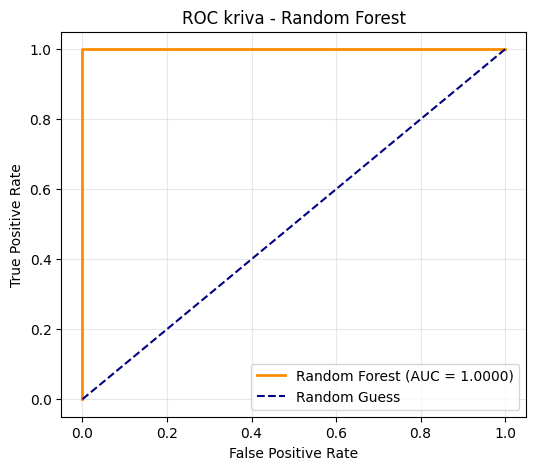

In [395]:
y_proba = random_forest_best.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, color='darkorange', linewidth=2, label=f"Random Forest (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], color='navy', linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC kriva - Random Forest")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

#### ROC kriva za Support Vector Machine

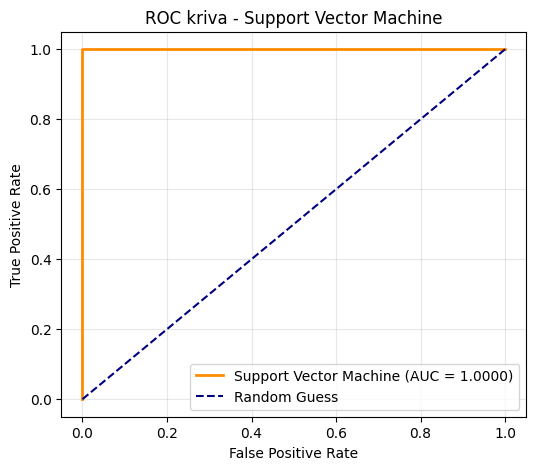

In [396]:
y_proba_svm = svm_best.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba_svm)
auc = roc_auc_score(y_test, y_proba_svm)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, color='darkorange', linewidth=2, label=f"Support Vector Machine (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], color='navy', linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC kriva - Support Vector Machine")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

### Interpretabilnost modela - feature importance (Random Forest)

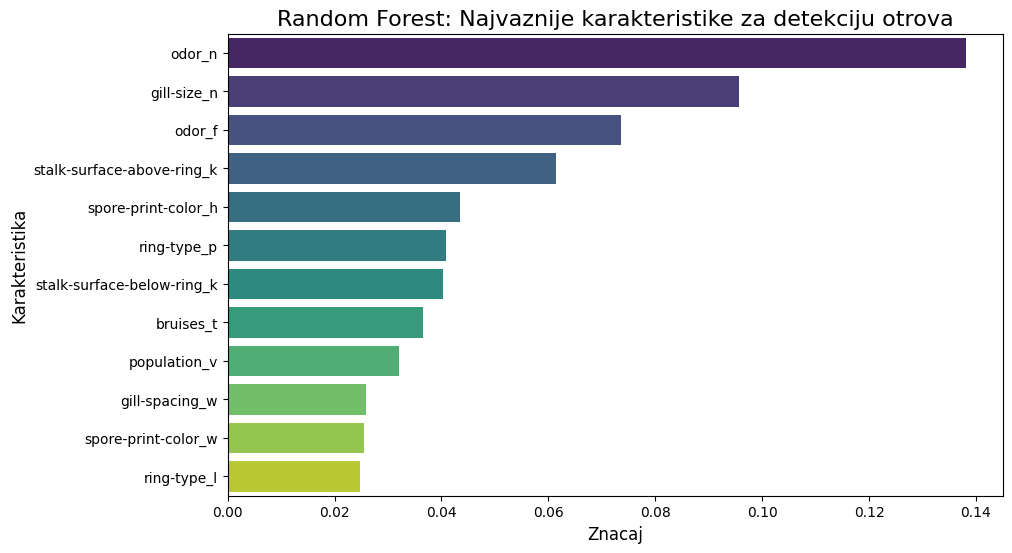

Najbitnija karakteristika je: odor_n


In [397]:
# Random Forest ima ugradjen feature importance
importances = random_forest_best.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(12), palette='viridis')

plt.title('Random Forest: Najvaznije karakteristike za detekciju otrova', fontsize=16)
plt.xlabel('Znacaj', fontsize=12)
plt.ylabel('Karakteristika', fontsize=12)
plt.show()

print("Najbitnija karakteristika je:", feature_importance_df.iloc[0]['Feature'])


#### Interpretabilnost modela - Shap analiza (Random Forest)

In [398]:
explainer = shap.TreeExplainer(random_forest_best)
shap_values = explainer.shap_values(X_test)

shap_values_poisonous = shap_values[:, :, 1]


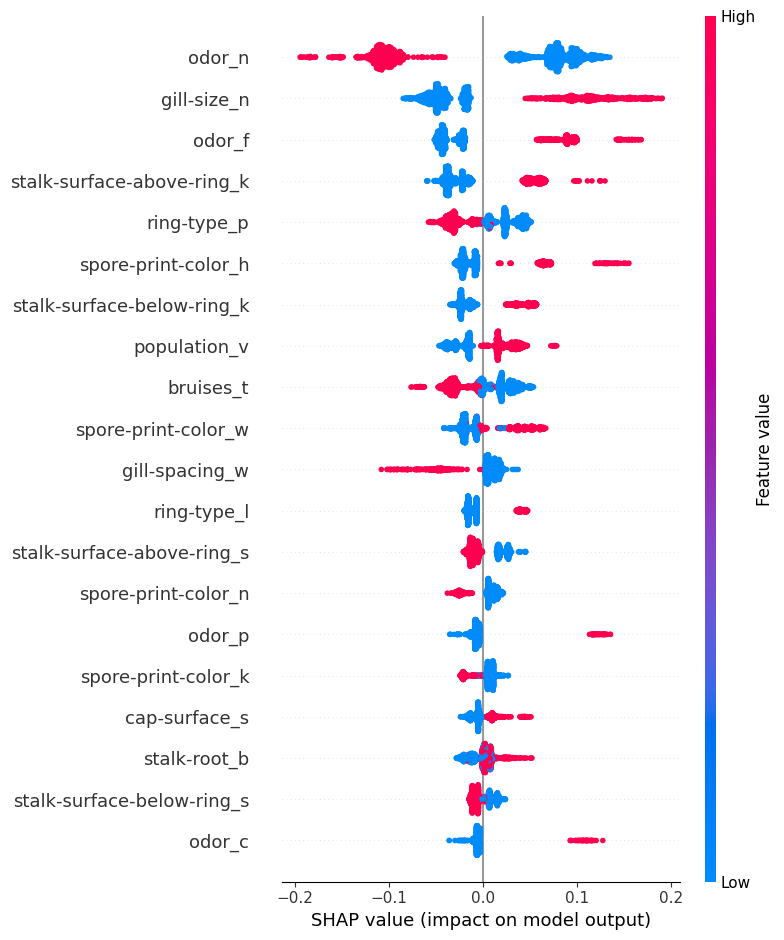

In [399]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_poisonous, X_test)
plt.show()

#### Random Forest Lime

In [400]:
rf_for_lime = random_forest_best

explainer_lime = LimeTabularExplainer(
    training_data=X_train.values.astype(float),
    feature_names=X_train.columns.tolist(),
    class_names=['Jestiva', 'Otrovna'],
    mode='classification'
)

# Uzimamo jednu otrovnu pecurku
poison_indicies = [i for i, x in enumerate(y_test) if x == 1]
index = poison_indicies[0]

print(f"Analiza uzorka sa indeksom: {index}")
print("Stvarna klasa: OTROVNA")


exp = explainer_lime.explain_instance(
    data_row=X_test.iloc[index].astype(float).values,
    predict_fn=random_forest_best.predict_proba,
    num_features=10
)

Analiza uzorka sa indeksom: 0
Stvarna klasa: OTROVNA


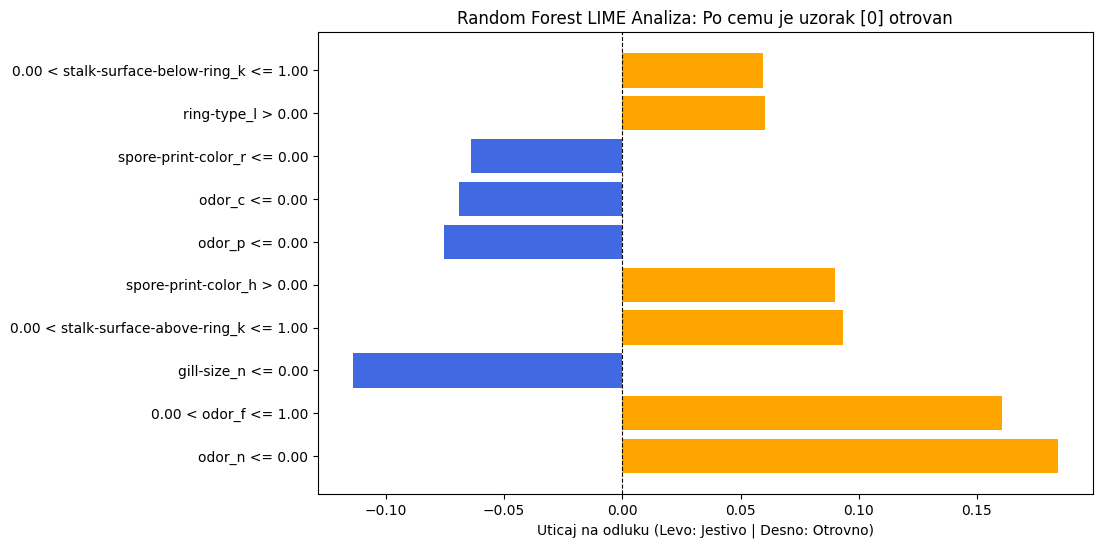

In [401]:
features, weights = zip(*exp.as_list())

colors = ['orange' if x > 0 else 'royalblue' for x in weights]

plt.figure(figsize=(10, 6))
plt.barh(features, weights, color=colors)

plt.title(f"Random Forest LIME Analiza: Po cemu je uzorak [{index}] otrovan")
plt.xlabel("Uticaj na odluku (Levo: Jestivo | Desno: Otrovno)")
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)

plt.show()

Dok nam SHAP analiza daje globalnu sliku o tome koji atributi su najvazniji za model, LIME metodu smo iskoristili da proverimo koliko je model pouzdan kada donosi odluke za pojedinacne primerke. Ova tehnika nam omogucava da vidimo zasto je bas taj konkretni uzorak klasifikovan kao otrovan.

Kada pogledamo grafik, jasno se vidi da su karakteristike mirisa (**odor_f** i **odor_n**) kljucni faktori na osnovu kojih model donosi odluku. Ovi rezultati se direktno poklapaju sa nalazima iz prethodne SHAP analize, sto potvrdjuje da model zaista koristi stabilna i bioloski smislena pravila za prepoznavanje otrovnih pecuraka, a ne samo nasumicne korelacije iz podataka.

#### Interpretabilnost modela - feature importance (Support Vector Machine)

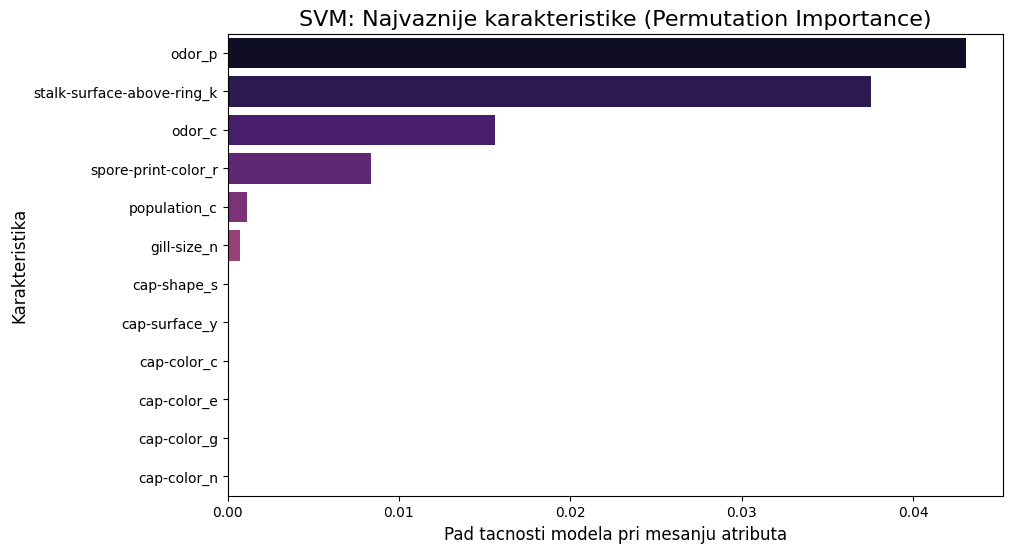

Najbitnija karakteristika za SVM je: odor_p


In [402]:
perm_importance = permutation_importance(svm_best, X_test, y_test, n_repeats=10, random_state=42)

feature_names = X_train.columns

svm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=svm_importance_df.head(12), palette='magma')

plt.title('SVM: Najvaznije karakteristike (Permutation Importance)', fontsize=16)
plt.xlabel('Pad tacnosti modela pri mesanju atributa', fontsize=12)
plt.ylabel('Karakteristika', fontsize=12)
plt.show()

print("Najbitnija karakteristika za SVM je:", svm_importance_df.iloc[0]['Feature'])

#### Interpretabilnost modela - Shap analiza (Support Vector Machine)

Racunam SHAP vrednosti, treba malo duze vremena...


100%|██████████| 50/50 [00:22<00:00,  2.23it/s]


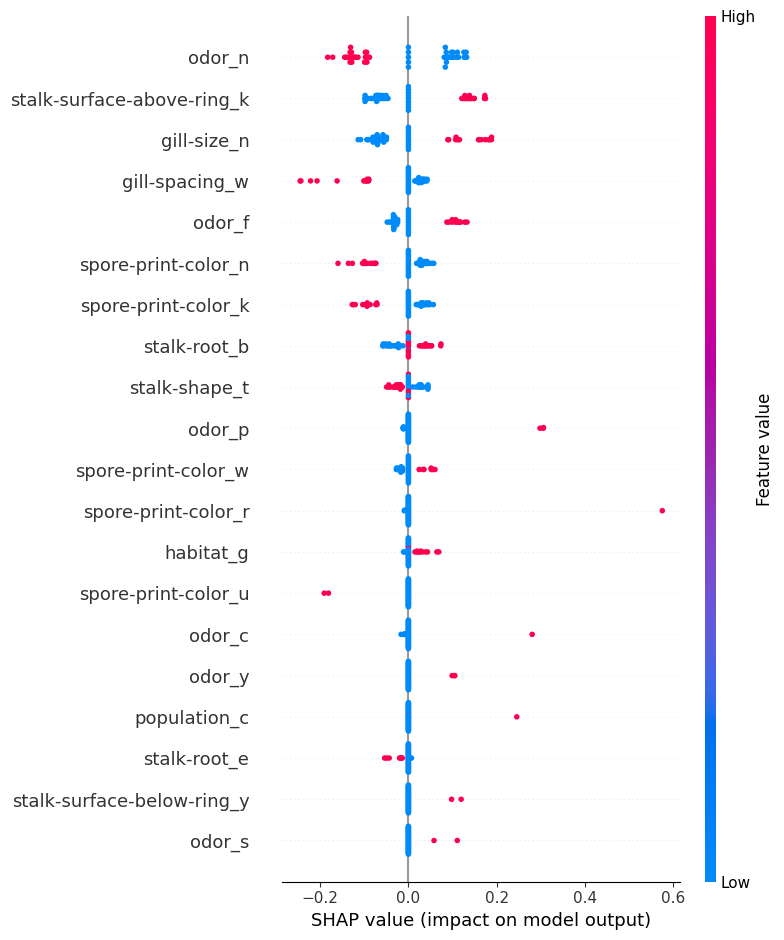

In [403]:
X_train_summary = shap.kmeans(X_train, 50)

explainer_svm = shap.KernelExplainer(svm_best.predict_proba, X_train_summary)

print("Racunam SHAP vrednosti, treba malo duze vremena...")
X_test_sample = X_test.iloc[:50] 
shap_values_svm = explainer_svm.shap_values(X_test_sample)

shap.summary_plot(
    shap_values_svm[:, :, 1],
    X_test_sample.values,
    feature_names=X_test.columns
)

#### Support Vector Machine Lime

In [404]:
explainer_lime_svm = LimeTabularExplainer(
    training_data=X_train.values.astype(float),
    feature_names=X_train.columns.tolist(),
    class_names=['Jestiva', 'Otrovna'],
    mode='classification',
    random_state=42
)

poison_indicies = [i for i, x in enumerate(y_test) if x == 1]
index = poison_indicies[0] # Uzimamo prvu nadjenu otrovnu pecurku

print(f"🔍 SVM LIME Analiza uzorka sa indeksom: {index}")
print("Stvarna klasa: OTROVNA")

exp_svm = explainer_lime_svm.explain_instance(
    data_row=X_test.iloc[index].astype(float).values,
    predict_fn=svm_best.predict_proba,
    num_features=10
)

🔍 SVM LIME Analiza uzorka sa indeksom: 0
Stvarna klasa: OTROVNA


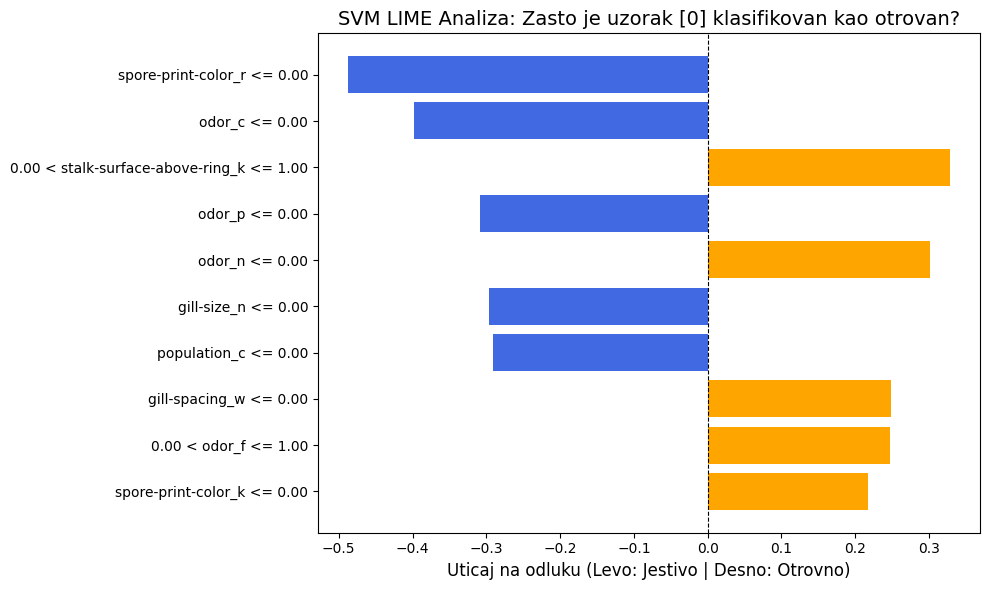

In [405]:
features, weights = zip(*exp_svm.as_list())

colors = ['orange' if x > 0 else 'royalblue' for x in weights]

plt.figure(figsize=(10, 6))
plt.barh(features, weights, color=colors)
plt.title(f"SVM LIME Analiza: Zasto je uzorak [{index}] klasifikovan kao otrovan?", fontsize=14)
plt.xlabel("Uticaj na odluku (Levo: Jestivo | Desno: Otrovno)", fontsize=12)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

U poredjenju sa Random Forest modelom, SHAP analiza za SVM pokazuje izuzetnu doslednost, jer je i ovaj algoritam nezavisno identifikovao miris (**odor**) kao presudan faktor za razlikovanje klasa. Pored toga, SVM je veliki znacaj pridao i teksturi drske (**stalk-surface-above-ring_k**), sto nam potvrdjuje da visoka tacnost modela nije slucajna, vec da oba algoritma uspesno detektuju iste, univerzalne bioloske signale opasnosti.

LIME analiza nojedinacnog otrovnog uzorka otkriva da je odluka doneta na osnovu jasnih fizickih karakteristika. Grafik pokazuje da je tekstura drske bila najjaci indikator otrovnosti, uz podrsku atributa mirisa (**odor_f**), koji su zajedno nadjacali manje bitne karakteristike poput boje spora. Ovakav uvid potvrdjuje da SVM ne radi kao "crna kutija", vec odluke donosi povezujuci fizicki izgled i miris gljive na logican nacin.

### Redukcija dimenzionalnosti (PCA)

In [406]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA()
pca.fit(X_train_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

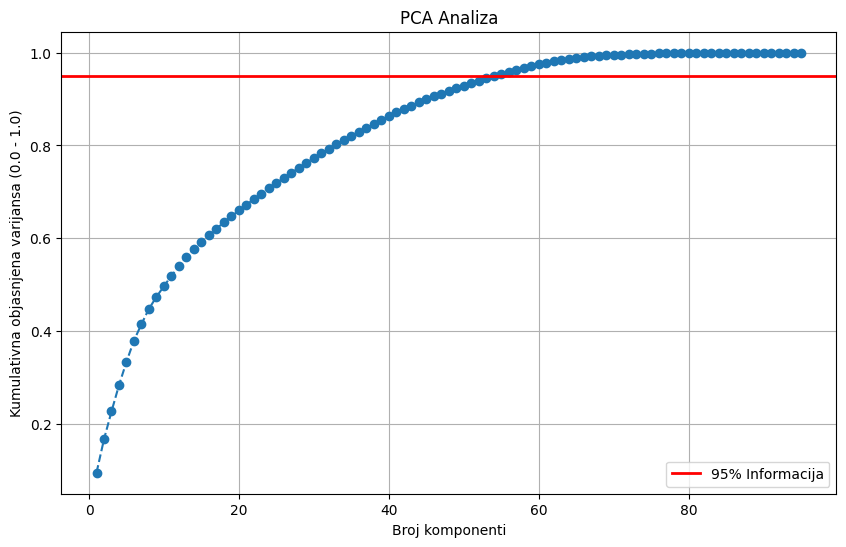

In [407]:
plt.figure(figsize=(10, 6))

plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker="o", linestyle='--')

plt.axhline(y=0.95, color='r', linestyle='-', linewidth=2, label='95% Informacija')

plt.xlabel("Broj komponenti")
plt.ylabel("Kumulativna objasnjena varijansa (0.0 - 1.0)")
plt.title("PCA Analiza")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Na osnovu grafika kumulativne objasnjene varijanse, uoceno je da oko 50 komponente (od ukupno 95) objasnjavaju 95% varijanse u podacima.

Kriva na grafiku nakon ove tacke ulazi u fazu zasicenja, sto znaci da preostali atributi doprinose minimalno novim informacijama. Zbog toga je doneta odluka da se izvrsi redukcija dimenzionalnosti na ovaj broj komponenti, cime se eliminise prezasicenost i ubrzava proces treniranja, dok se gubitak informacija odrzava ispod 5%

In [408]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

num_components = X_train_pca.shape[1]

print(f"Originalna dimenzija: {X_train_scaled.shape[1]}")
print(f"Nova dimenzija (PCA): {num_components}")
print(f"Smanjenje za: {X_train_scaled.shape[1] - num_components} kolona")
print("-"*50)

Originalna dimenzija: 95
Nova dimenzija (PCA): 55
Smanjenje za: 40 kolona
--------------------------------------------------


#### Treniranje Random Foresta sa novim dimenzijama

In [409]:
best_params = random_forest_best.get_params()

rf_pca = RandomForestClassifier(**best_params)
rf_pca.fit(X_train_pca, y_train)

y_pred_pca = rf_pca.predict(X_test_pca)

y_pred_orig = random_forest_best.predict(X_test)
accuracy_original = accuracy_score(y_test, y_pred_orig)
recall_original = recall_score(y_test, y_pred_orig)
pre_original = precision_score(y_test, y_pred_orig)

acc_pca = accuracy_score(y_test, y_pred_pca)
rec_pca = recall_score(y_test, y_pred_pca)
pre_pca = precision_score(y_test, y_pred_pca)


print("="*60)
print(f"Random Forest")
print("="*60)
print(f"ORIGINALNI MODEL")
print("="*60)
print(classification_report(y_test, y_pred_orig, target_names=['Jestiva', 'Otrovna']))

print("\n" + "="*60)
print(f"PCA MODEL (Redukovani atributi)")
print("="*60)
print(classification_report(y_test, y_pred_pca, target_names=['Jestiva', 'Otrovna']))

Random Forest
ORIGINALNI MODEL
              precision    recall  f1-score   support

     Jestiva       1.00      1.00      1.00       842
     Otrovna       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625


PCA MODEL (Redukovani atributi)
              precision    recall  f1-score   support

     Jestiva       1.00      1.00      1.00       842
     Otrovna       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [410]:
best_params_svm = svm_best.get_params()

svm_pca = SVC(**best_params_svm)
svm_pca.fit(X_train_pca, y_train)

y_pred_pca_svm = svm_pca.predict(X_test_pca)

y_pred_orig_svm = svm_best.predict(X_test)
accuracy_original_svm = accuracy_score(y_test, y_pred_orig_svm)
recall_original_svm = recall_score(y_test, y_pred_orig_svm)
pre_original_svm = precision_score(y_test, y_pred_orig_svm)

acc_pca_svm = accuracy_score(y_test, y_pred_pca_svm)
rec_pca_svm = recall_score(y_test, y_pred_pca_svm)
pre_pca_svm = precision_score(y_test, y_pred_pca_svm)


print("="*60)
print(f"Support Vector Machine")
print("="*60)
print(f"ORIGINALNI MODEL")
print("="*60)
print(classification_report(y_test, y_pred_orig_svm, target_names=['Jestiva', 'Otrovna']))

print("\n" + "="*60)
print(f"PCA MODEL (Redukovani atributi)")
print("="*60)
print(classification_report(y_test, y_pred_pca_svm, target_names=['Jestiva', 'Otrovna']))

Support Vector Machine
ORIGINALNI MODEL
              precision    recall  f1-score   support

     Jestiva       1.00      1.00      1.00       842
     Otrovna       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625


PCA MODEL (Redukovani atributi)
              precision    recall  f1-score   support

     Jestiva       1.00      1.00      1.00       842
     Otrovna       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [411]:
comparison = pd.DataFrame({
    'Model': ['Random Forest: Original', 'Support Vector Machine: Original', 'Random Forest: PCA', 'Support Vector Machine: PCA'],
    'Accuracy': [accuracy_original, accuracy_original_svm, acc_pca, acc_pca_svm],
    'Recall': [recall_original, recall_original_svm, rec_pca, rec_pca_svm],
    'Precision': [pre_original, pre_original_svm, pre_pca, pre_pca_svm]
})

print("\n" + "="*60)
print("DIREKTNO POREDJENJE KLJUCNIH METRIKA")
print("="*60)
print(comparison.to_string(index=False))


DIREKTNO POREDJENJE KLJUCNIH METRIKA
                           Model  Accuracy   Recall  Precision
         Random Forest: Original  1.000000 1.000000        1.0
Support Vector Machine: Original  1.000000 1.000000        1.0
              Random Forest: PCA  0.999385 0.998723        1.0
     Support Vector Machine: PCA  1.000000 1.000000        1.0


### Diskusija rezultata nakon PCA analize

Nakon primene PCA transformacije, trenirani su isti klasifikacioni modeli (Random Forest i Support Vector Machine) nad redukovanim skupom podataka. Poredjenjem dobijenih metrika (Accuracy, Precision, Recall i F1-score) sa originalnim modelom, uocava se da su performanse ostale gotovo identicne, uz minimalan gubitak u osetljivosti modela.


Ovi rezultati ukazuju na tri kljucna zakljucka:

* Visoka redundantnost atributa: Originalni skup podataka sadrzi visok stepen multikolinearnosti; veliki broj atributa nosi iste ili slicne informacije.
* Uspesna kompresija: PCA je uspesno sazela podatke zadrzavajuci kljucne obrasce neophodne za klasifikaciju.
* Trade-off: Iako je model nad redukovanim podacima brzi, primena PCA drasticno smanjuje interpretabilnost. Transformacijom u glavne komponente gubi se direktna veza sa bioloskim osobinama (npr. miris, boja), zbog cega vise nije moguce intuitivno objasniti razloge za donosenje odluke.

### Poredjenje performansi modela

U tabeli ispod prikazano je poredjenje performansi Random Forest modela na test skupu pre i posle redukcije dimenzionalnosti. Poseban fokus stavljen je na detekciju otrovne klase.

| Model | Accuracy | Precision | Recall | Precision |
|-------|----------|-----------|------------------|---------------------|
| Random Forest | 1.000000 | 1.0| 1.000000 | 1.0 |
| Support Vector Machine | 1.000000 | 1.0| 1.000000 | 1.0 |
| Random Forest PCA | 0.999385 | 1.0 | 0.998723 | 1.0 |
| Support Vector Machine PCA | 1.000000 | 1.0 | 1.000000 | 1.0 |

#### Analiza rezultata:

**Random Forest (Original):** Model sa svim originalnim atributima postize savrsene rezultate, bez i jedne greske klasifikuje svih 1625 testnih primera. Ovo nam pokazuje da originalni podaci sadrze sve sto je potrebno da se potpuno pouzdano razdvoje otrovne od jestivih gljiva.

**Random Forest + PCA:** Model treniran na redukovanom prostoru (oko 53 komponente) postize izuzetno visoku tacnost od 99.94%. Doslo je do minimalnog pada u Recall vrednosti (sa 1.00 na 0.9987), sto u apsolutnim brojevima predstavlja samo jednu pogresnu klasifikaciju na celom test setu.

Medjutim, u praksi, ovakav pad performansi je kritican. Ta jedna greska predstavlja lazno negativan rezultat  u kojoj model otrovnu pecurku proglasava jestivom. Dok lazno pozitivna greska (proglasavanje jestive pecurke otrovnom) rezultuje samo ekonomskim gubitkom (bacanjem hrane), lazno negativna greska nosi rizik od trovanja sa potencijalno fatalnim ishodom.

**Support Vector Machine (Original):** Identicno kao i kod Random Foresta, SVM model nad originalnim skupom podataka postize idealne performanse sa rezultatom 1.00 za sve metrike. Ovo sluzi kao dvostruka potvrda kvaliteta podataka. Cinjenica da dva algoritma sa potpuno razlicitim matematickim osnovama (jedan baziran na drvecu, drugi na vektorima i hiper-ravnima) postizu savrsenstvo, dokazuje da u originalnim atributima postoji jasan i nedvosmislen signal za razlikovanje klasa.

**Support Vector Machine + PCA:** Za razliku od Random Foresta koji je nakon redukcije dimenzionalnosti napravio jednu kriticnu gresku, SVM model je zadrzao apsolutnu tacnost (Recall = 1.00) cak i nad redukovanim podacima.

Ovo ukazuje na to da je SVM pokazao vecu robustnost na gubitak informacija (5% varijanse odbacenih tokom PCA). Dok je Random Forest izgubio onaj fini detalj potreban za klasifikaciju tog jednog teskog primera, SVM je uspeo da pronadje optimalnu hiper-ravan koja i dalje savrseno razdvaja klase u kompresovanom prostoru.

**Zakljucak:**
Iako su oba modela savrsena na originalnom skupu, SVM odnosi pobedu u testu sa redukovanim podacima. U scenariju gde smo primorani da koristimo PCA (zbog brzine ili memorije), SVM se pokazao kao bezbedniji izbor jer jedini garantuje 0% lazno negativnih rezultata (Recall = 1.0), sto je najvazniji kriterijum u domenu toksikologije.